In [37]:
import tifffile as tiff
import numpy as np
from pathlib import Path
import pandas as pd
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [38]:
root = Path("/Volumes/HELHEIM/analyzed_data/heat_shock/raw_data_KT/20260114_RNAscope_bactin-561_Nos-633_Vasa-488_Tg24_12hpf_heat-shock_vs_ctrl")

In [39]:
list_of_sample_paths = [pth for pth in root.iterdir() if pth.is_dir() and not pth.name.startswith('.')]
for sample_path in list_of_sample_paths:
    sample_dict = {}
    uid, filename = sample_path.name.split('__')
    condition, sample_number = filename.split('-')


In [40]:
def compute_masks(seg_cell, seg_nucleus, seg_granule, safety_margin=2):
    """
    Compute binary masks for cell, nucleus, granules, and cytoplasm based on segmentations. The cytoplasm mask is defined as the cell mask minus the nucleus and granule masks, with an optional safety margin to avoid overlap.
    Args:
        seg_cell:
        seg_nucleus:
        seg_granule:
        safety_margin:

    Returns: Cell mask, nucleus mask, granule mask, cytoplasm mask

    """
    # Create binary masks
    cell_mask = seg_cell > 0
    nucleus_mask = seg_nucleus > 0
    granule_mask = seg_granule > 0

    # Only consider granules within cells
    granule_mask = granule_mask & cell_mask

    # Only consider nucleus within cells
    nucleus_mask = nucleus_mask & cell_mask

    # Cytoplasm mask is cell minus nucleus and granules with safety margin
    nucleus_granule_mask = nucleus_mask | granule_mask
    distance_map = distance_transform_edt(~nucleus_granule_mask)
    cytoplasm_mask = cell_mask & (distance_map > safety_margin)
    return cell_mask, nucleus_mask, granule_mask, cytoplasm_mask

In [41]:
sample_path = list_of_sample_paths[0]

In [42]:
measurement_dicts = []
for sample_path in tqdm(list_of_sample_paths):
    # print(f'Processing sample: {sample_path.name}')
    save_figures = False  # Set to True to save figures for each sample


    sample_dict = {}

    uid, filename = sample_path.name.split('__')
    condition, sample_number = filename.split('-')

    sample_dict.update({
        'sample_path': sample_path,
        'uid': uid,
        'condition': condition,
        'sample_number': sample_number,
        'is_PGC': False if 'soma' in condition.lower() else True,
        "is_heatshock": True if 'heat' in condition.lower() else False
    })

    img_rna_actin_path = sample_path / "raw" / "bact_rna.tiff"
    img_granule_path = sample_path / "raw" / "granule.tiff"
    img_rna_nanos_path = sample_path / "raw" / "nos_rna.tiff"
    img_nucleus_path = sample_path / "raw" / "nucleus.tiff"

    seg_granule_path = sample_path / "segmentations" / "granule.tiff"
    seg_nucleus_path = sample_path / "segmentations" / "nucleus.tiff"
    seg_cell_path = sample_path / "segmentations" / "cell.tiff"


    img_rna_actin = tiff.imread(img_rna_actin_path)
    img_granule = tiff.imread(img_granule_path)
    img_rna_nanos = tiff.imread(img_rna_nanos_path)
    img_nucleus = tiff.imread(img_nucleus_path)

    img_seg_granule = tiff.imread(seg_granule_path)
    img_seg_nucleus = tiff.imread(seg_nucleus_path)
    img_seg_cell = tiff.imread(seg_cell_path)

    mask_cell, mask_nucleus, mask_granule, mask_cytoplasm = compute_masks(
        img_seg_cell, img_seg_nucleus, img_seg_granule, safety_margin=2)

    # Measure and store relevant intensies
    areas_to_measure = {
        "cytoplasm": mask_cytoplasm,
        "nucleus": mask_nucleus,
        "granules": mask_granule,
        "cell": mask_cell
    }

    images_to_measure = {
        "bactin_rna": img_rna_actin,
        "nanos_rna": img_rna_nanos,
        "granules": img_granule
    }

    for area_name, area_mask in areas_to_measure.items():
        for image_name, image in images_to_measure.items():
            mean_intensity = np.mean(image[area_mask])
            total_intensity = np.sum(image[area_mask])
            area_size = np.sum(area_mask)
            measurement_dict = sample_dict.copy()
            measurement_dict.update({
                "area_name": area_name,
                "marker_name": image_name,
                "mean_intensity": mean_intensity,
                "total_intensity": total_intensity,
                "area_size": area_size
            })
            measurement_dicts.append(measurement_dict)

        if save_figures:
            # Plot raw images and segmentations
            figs, axs = plt.subplots(2, 4, figsize=(10, 5))
            # Top row: raw images
            axs[0, 0].imshow(img_nucleus, cmap='gray')
            axs[0, 0].set_title('Nucleus')
            axs[0, 1].imshow(img_granule, cmap='gray')
            axs[0, 1].set_title('Granules')
            axs[0, 2].imshow(img_rna_actin, cmap='gray')
            axs[0, 2].set_title('Bactin RNA')
            axs[0, 3].imshow(img_rna_nanos, cmap='gray')
            axs[0, 3].set_title('Nanos RNA')

            # Bottom row: segmentations
            axs[1, 0].imshow(img_seg_nucleus, cmap='gray')
            axs[1, 0].set_title('Nucleus Segmentation')
            axs[1, 1].imshow(img_seg_granule, cmap='gray')
            axs[1, 1].set_title('Granule Segmentation')
            axs[1, 2].imshow(img_seg_cell, cmap='gray')
            axs[1, 2].set_title('Cell Segmentation')
            axs[1, 3].imshow(mask_cytoplasm, cmap='gray')
            axs[1, 3].set_title('Cytoplasm Mask')
            plt.tight_layout()
            for ax in axs.flat:
                ax.axis('off')
            figs.suptitle(f'Sample: {sample_path.name}', y=1.02)
            figs.savefig(sample_path / f'{sample_path.name}_overview.png', bbox_inches='tight')
            plt.close(figs)



100%|██████████| 61/61 [00:01<00:00, 37.18it/s]


In [43]:
df_main = pd.DataFrame(measurement_dicts)

In [44]:
df_main

,sample_path,uid,condition,sample_number,is_PGC,is_heatshock,area_name,marker_name,mean_intensity,total_intensity,area_size
0,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,cytoplasm,bactin_rna,1518.902797,65988732,43445
1,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,cytoplasm,nanos_rna,285.076004,12385127,43445
2,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,cytoplasm,granules,1952.838808,84841082,43445
3,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,nucleus,bactin_rna,1724.388144,42063000,24393
4,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,29b45ed029d249d096395450efac9500,control,11,True,False,nucleus,nanos_rna,331.517690,8086711,24393
...,...,...,...,...,...,...,...,...,...,...,...
727,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,1f239bdf5cfa44cb8d12a8ed4a7269fb,somaHeatshock,7,False,True,granules,nanos_rna,182.203033,1021248,5605
728,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,1f239bdf5cfa44cb8d12a8ed4a7269fb,somaHeatshock,7,False,True,granules,granules,7543.347547,42280463,5605
729,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,1f239bdf5cfa44cb8d12a8ed4a7269fb,somaHeatshock,7,False,True,cell,bactin_rna,2276.540065,526622907,231326
730,/Volumes/HELHEIM/analyzed_data/heat_shock/raw_...,1f239bdf5cfa44cb8d12a8ed4a7269fb,somaHeatshock,7,False,True,cell,nanos_rna,183.510734,42450804,231326


In [45]:
# Calculate per cell ratios of cytoplasm to granule intensities for all marker_names
df_cytoplasm_granule_ratio = df_main.pivot_table(
    index=['uid', 'condition', 'sample_number', 'is_PGC', 'is_heatshock', 'marker_name'],
    columns='area_name',
    values='mean_intensity'
).reset_index()
df_cytoplasm_granule_ratio['cytoplasm_to_granule_ratio'] = (
    df_cytoplasm_granule_ratio['cytoplasm'] / df_cytoplasm_granule_ratio['granules']
)


In [46]:
df_cytoplasm_granule_ratio

area_name,uid,condition,sample_number,is_PGC,is_heatshock,marker_name,cell,cytoplasm,granules,nucleus,cytoplasm_to_granule_ratio
0,0062b885e11647929eaaceca7ba06389,control,19,True,False,bactin_rna,4756.127832,3712.489484,18764.290096,2783.510312,0.197849
1,0062b885e11647929eaaceca7ba06389,control,19,True,False,granules,4817.854593,3232.438241,21746.999796,4392.929364,0.148638
2,0062b885e11647929eaaceca7ba06389,control,19,True,False,nanos_rna,1602.849193,973.211216,8633.537090,937.476303,0.112725
3,009cdd5831664ed9a0ce8e9a8aa4db72,somaHeatshock,9,False,True,bactin_rna,1894.109365,2206.697408,2985.195617,1431.575675,0.739214
4,009cdd5831664ed9a0ce8e9a8aa4db72,somaHeatshock,9,False,True,granules,1281.176166,1126.254121,7469.854593,1186.609004,0.150773
...,...,...,...,...,...,...,...,...,...,...,...
178,f66cfcdcb39a4d31a596e26bc4202e1b,heatshock,10,True,True,granules,14478.071298,6982.450568,38707.223372,6075.334929,0.180391
179,f66cfcdcb39a4d31a596e26bc4202e1b,heatshock,10,True,True,nanos_rna,7125.838677,2018.973820,21759.136740,3241.155433,0.092787
180,f849b09d8946486983728c54ee3d1223,heatshock,18,True,True,bactin_rna,5816.589189,4370.816467,23893.806230,2356.057103,0.182927
181,f849b09d8946486983728c54ee3d1223,heatshock,18,True,True,granules,6911.625774,5260.054238,28664.786005,2620.798563,0.183502


In [47]:
# Make palette for heatshock and control
heat_shock_palette = {
    True: '#D95F02',
    False: '#999999'
}

# Make PGC and soma palette
pgc_soma_palette = {
    True: "#DA3EB6",
    False: "#555555"}

marker_labels = {
    "bactin_rna": r"$\beta$actin",
    "nanos_rna": "nanos3",
    "granules": "Vasa"}

In [48]:
df_main['marker_name'].unique()

array(['bactin_rna', 'nanos_rna', 'granules'], dtype=object)

/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/312330698.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_cyto_gran_ratio.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_cyto_gran_ratio.get_xticklabels()], fontsize=12)
/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/312330698.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_cyto_gran_ratio.set_yticklabels(ax_pgc_cyto_gran_ratio.get_yticklabels(), fontsize=12)


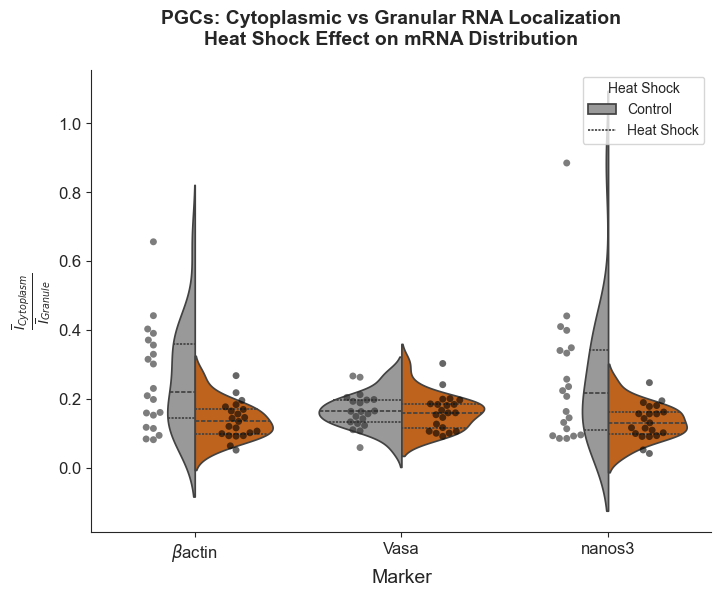

In [49]:
sns.set_style(style="ticks")
plt.rcParams['pdf.fonttype'] = 42

fig_pgc_cyto_gran_ratio, ax_pgc_cyto_gran_ratio = plt.subplots(figsize=(8, 6))
fig_pgc_cyto_gran_ratio.suptitle('PGCs: Cytoplasmic vs Granular RNA Localization\nHeat Shock Effect on mRNA Distribution', fontsize=14, fontweight='bold')
sns.violinplot(data=df_cytoplasm_granule_ratio.query("is_PGC == True"),
               x='marker_name',
               y='cytoplasm_to_granule_ratio',
               hue='is_heatshock',
               split=True,
               palette=heat_shock_palette,
               inner='quart',
               ax=ax_pgc_cyto_gran_ratio)
sns.swarmplot(data=df_cytoplasm_granule_ratio.query("is_PGC == True"),
              x='marker_name',
              y='cytoplasm_to_granule_ratio',
              hue='is_heatshock',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_pgc_cyto_gran_ratio)
ax_pgc_cyto_gran_ratio.set_ylabel(r"$\frac{\overline{I}_{Cytoplasm}}{\overline{I}_{Granule}}$", fontsize=14)
ax_pgc_cyto_gran_ratio.set_xlabel("Marker", fontsize=14)
ax_pgc_cyto_gran_ratio.legend(title='Heat Shock', labels=['Control', 'Heat Shock'], loc='upper right')
ax_pgc_cyto_gran_ratio.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_cyto_gran_ratio.get_xticklabels()], fontsize=12)
ax_pgc_cyto_gran_ratio.set_yticklabels(ax_pgc_cyto_gran_ratio.get_yticklabels(), fontsize=12)
sns.despine()
fig_pgc_cyto_gran_ratio.savefig(root / 'pgc_cytoplasm_granule_ratio_heatshock_effect.pdf', bbox_inches='tight')

/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/1261519530.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_soma_comparison.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_soma_comparison.get_xticklabels()], fontsize=12)


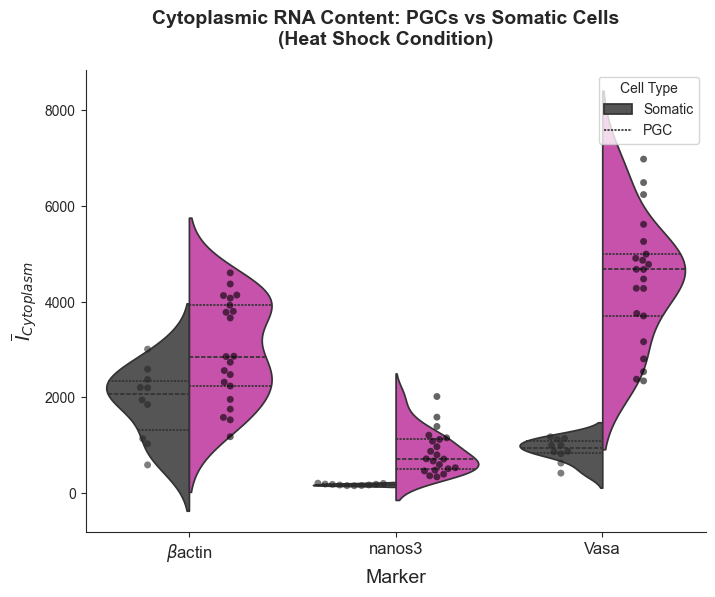

In [50]:
fig_pgc_soma_comparison, ax_pgc_soma_comparison = plt.subplots(figsize=(8, 6))
fig_pgc_soma_comparison.suptitle('Cytoplasmic RNA Content: PGCs vs Somatic Cells\n(Heat Shock Condition)', fontsize=14, fontweight='bold')
sns.violinplot(data=df_main.query("area_name == 'cytoplasm' and is_heatshock == True"),
               x='marker_name',
               y='mean_intensity',
               hue='is_PGC',
               split=True,
               palette=pgc_soma_palette,
               inner='quart',
               ax=ax_pgc_soma_comparison,
               density_norm="width")
sns.swarmplot(data=df_main.query("area_name == 'cytoplasm' and is_heatshock == True"),
              x='marker_name',
              y='mean_intensity',
              hue='is_PGC',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_pgc_soma_comparison)
ax_pgc_soma_comparison.set_ylabel(r"$\overline{I}_{Cytoplasm}$", fontsize=14)
ax_pgc_soma_comparison.set_xlabel("Marker", fontsize=14)
ax_pgc_soma_comparison.legend(title='Cell Type', labels=['Somatic', 'PGC'], loc='upper right')
ax_pgc_soma_comparison.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_soma_comparison.get_xticklabels()], fontsize=12)
sns.despine()
fig_pgc_soma_comparison.savefig(root / 'pgc_soma_cytoplasm_heatshock_comparison.pdf', bbox_inches='tight')

/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/1990373233.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_soma_cyto_gran_ratio.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_soma_cyto_gran_ratio.get_xticklabels()], fontsize=12)


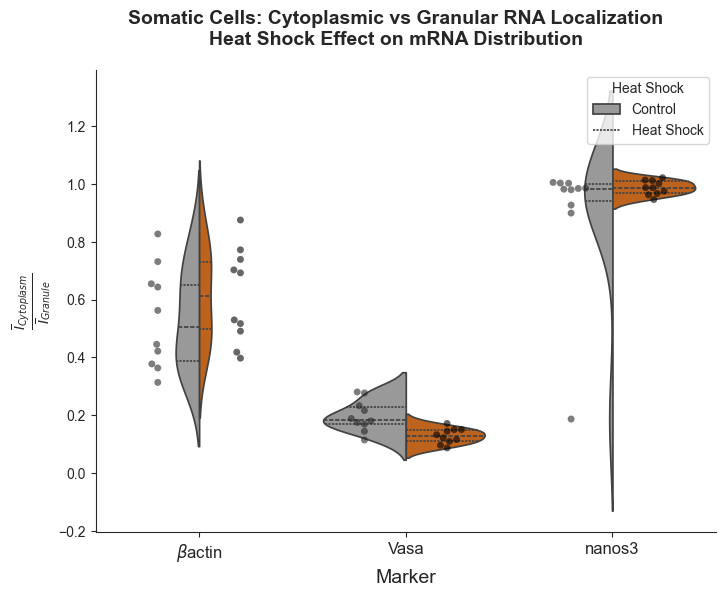

In [51]:
fig_soma_cyto_gran_ratio, ax_soma_cyto_gran_ratio = plt.subplots(figsize=(8, 6))
fig_soma_cyto_gran_ratio.suptitle('Somatic Cells: Cytoplasmic vs Granular RNA Localization\nHeat Shock Effect on mRNA Distribution', fontsize=14, fontweight='bold')
sns.violinplot(data=df_cytoplasm_granule_ratio.query("is_PGC == False"),
               x='marker_name',
               y='cytoplasm_to_granule_ratio',
               hue='is_heatshock',
               split=True,
                palette=heat_shock_palette,
               inner='quart',
               ax=ax_soma_cyto_gran_ratio)
sns.swarmplot(data=df_cytoplasm_granule_ratio.query("is_PGC == False"),
              x='marker_name',
              y='cytoplasm_to_granule_ratio',
              hue='is_heatshock',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_soma_cyto_gran_ratio)
ax_soma_cyto_gran_ratio.set_ylabel(r"$\frac{\overline{I}_{Cytoplasm}}{\overline{I}_{Granule}}$", fontsize=14)
ax_soma_cyto_gran_ratio.set_xlabel("Marker", fontsize=14)
ax_soma_cyto_gran_ratio.legend(title='Heat Shock', labels=['Control', 'Heat Shock'], loc='upper right')
ax_soma_cyto_gran_ratio.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_soma_cyto_gran_ratio.get_xticklabels()], fontsize=12)
sns.despine()
fig_soma_cyto_gran_ratio.savefig(root / 'soma_cytoplasm_granule_ratio_heatshock_effect.pdf', bbox_inches='tight')

/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/2229213684.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_soma_heatshock_effect.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_soma_heatshock_effect.get_xticklabels()], fontsize=12)


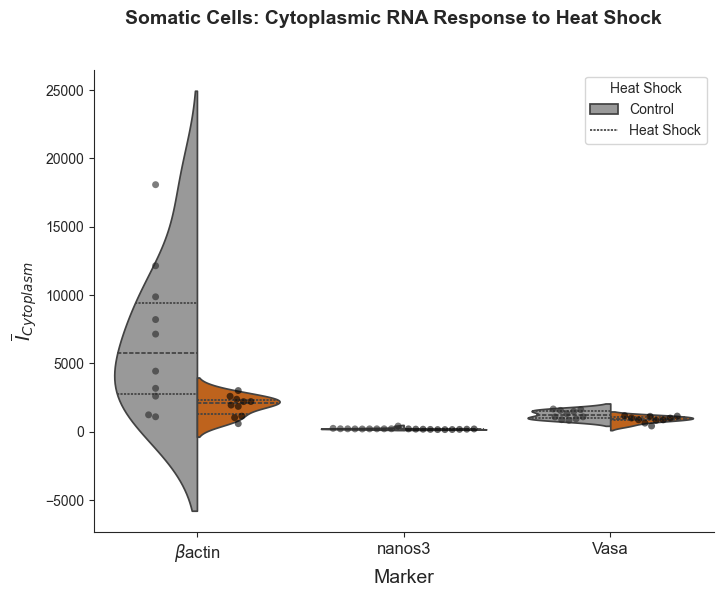

In [52]:
fig_soma_heatshock_effect, ax_soma_heatshock_effect = plt.subplots(figsize=(8, 6))
fig_soma_heatshock_effect.suptitle('Somatic Cells: Cytoplasmic RNA Response to Heat Shock', fontsize=14, fontweight='bold')
sns.violinplot(data=df_main.query("area_name == 'cytoplasm' and is_PGC == False"),
               x='marker_name',
               y='mean_intensity',
               hue='is_heatshock',
               split=True,
               palette=heat_shock_palette,
               inner='quart',
               ax=ax_soma_heatshock_effect,
               density_norm="width")
sns.swarmplot(data=df_main.query("area_name == 'cytoplasm' and is_PGC == False"),
              x='marker_name',
              y='mean_intensity',
              hue='is_heatshock',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_soma_heatshock_effect)
ax_soma_heatshock_effect.set_ylabel(r"$\overline{I}_{Cytoplasm}$", fontsize=14)
ax_soma_heatshock_effect.set_xlabel("Marker", fontsize=14)
ax_soma_heatshock_effect.legend(title='Heat Shock', labels=['Control', 'Heat Shock'], loc='upper right')
ax_soma_heatshock_effect.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_soma_heatshock_effect.get_xticklabels()], fontsize=12)
sns.despine()
fig_soma_heatshock_effect.savefig(root / 'soma_cytoplasm_heatshock_effect.pdf', bbox_inches='tight')

/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/763460865.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_heatshock_effect.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_heatshock_effect.get_xticklabels()], fontsize=12)


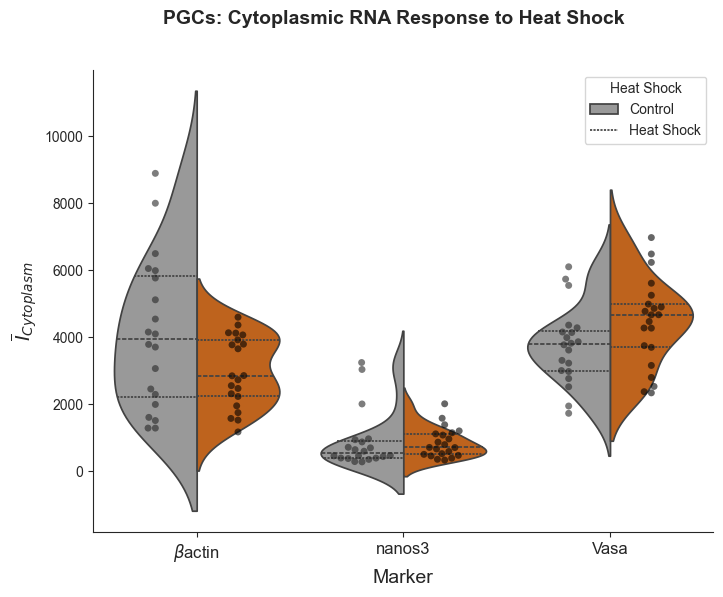

In [53]:
fig_pgc_heatshock_effect, ax_pgc_heatshock_effect = plt.subplots(figsize=(8, 6))
fig_pgc_heatshock_effect.suptitle('PGCs: Cytoplasmic RNA Response to Heat Shock', fontsize=14, fontweight='bold')
sns.violinplot(data=df_main.query("area_name == 'cytoplasm' and is_PGC == True"),
               x='marker_name',
               y='mean_intensity',
               hue='is_heatshock',
               split=True,
               inner='quart',
                palette=heat_shock_palette,
               ax=ax_pgc_heatshock_effect,
               density_norm="width")
sns.swarmplot(data=df_main.query("area_name == 'cytoplasm' and is_PGC == True"),
              x='marker_name',
              y='mean_intensity',
              hue='is_heatshock',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_pgc_heatshock_effect)
ax_pgc_heatshock_effect.set_ylabel(r"$\overline{I}_{Cytoplasm}$", fontsize=14)
ax_pgc_heatshock_effect.set_xlabel("Marker", fontsize=14)
ax_pgc_heatshock_effect.legend(title='Heat Shock', labels=['Control', 'Heat Shock'], loc='upper right')
ax_pgc_heatshock_effect.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_heatshock_effect.get_xticklabels()], fontsize=12)
sns.despine()
fig_pgc_heatshock_effect.savefig(root / 'pgc_cytoplasm_heatshock_effect.pdf', bbox_inches='tight')

In [54]:
# Sum intenisties of cytoplasm

# Calculate per cell ratios of cytoplasm to granule intensities for all marker_names
df_cytoplasm_granule_ratio_sum = df_main.pivot_table(
    index=['uid', 'condition', 'sample_number', 'is_PGC', 'is_heatshock', 'marker_name'],
    columns='area_name',
    values='total_intensity'
).reset_index()
df_cytoplasm_granule_ratio_sum['cytoplasm_to_granule_ratio'] = (
    df_cytoplasm_granule_ratio_sum['cytoplasm'] / df_cytoplasm_granule_ratio_sum['granules']
)
df_cytoplasm_granule_ratio_sum['portion_cytoplasm_to_granule_ratio'] = (df_cytoplasm_granule_ratio_sum["cytoplasm"] / (df_cytoplasm_granule_ratio_sum["cytoplasm"] + df_cytoplasm_granule_ratio_sum["granules"]))

/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/743006606.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_cyto_gran_ratio_sum.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_cyto_gran_ratio_sum.get_xticklabels()], fontsize=12)
/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/743006606.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_cyto_gran_ratio_sum.set_yticklabels(ax_pgc_cyto_gran_ratio_sum.get_yticklabels(), fontsize=12)


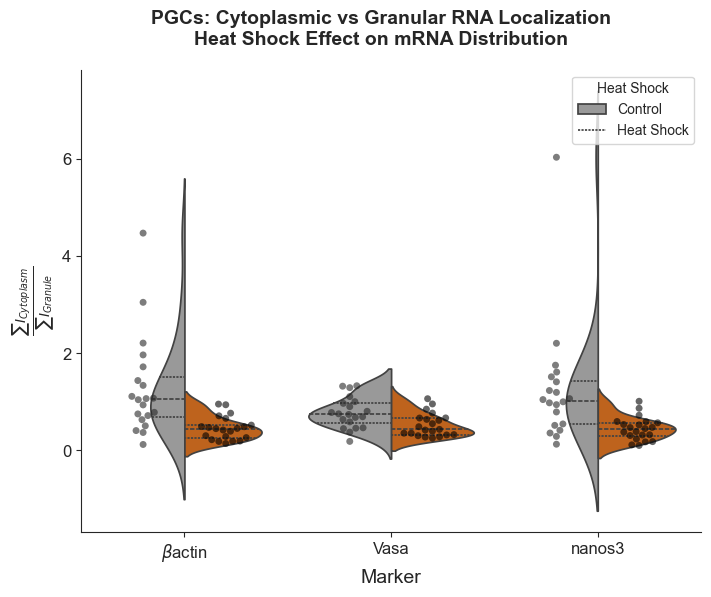

In [55]:
fig_pgc_cyto_gran_ratio_sum, ax_pgc_cyto_gran_ratio_sum = plt.subplots(figsize=(8, 6))
fig_pgc_cyto_gran_ratio_sum.suptitle('PGCs: Cytoplasmic vs Granular RNA Localization\nHeat Shock Effect on mRNA Distribution', fontsize=14, fontweight='bold')
sns.violinplot(data=df_cytoplasm_granule_ratio_sum.query("is_PGC == True"),
               x='marker_name',
               y='cytoplasm_to_granule_ratio',
               hue='is_heatshock',
               split=True,
               palette=heat_shock_palette,
               inner='quart',
               ax=ax_pgc_cyto_gran_ratio_sum)
sns.swarmplot(data=df_cytoplasm_granule_ratio_sum.query("is_PGC == True"),
              x='marker_name',
              y='cytoplasm_to_granule_ratio',
              hue='is_heatshock',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_pgc_cyto_gran_ratio_sum)
ax_pgc_cyto_gran_ratio_sum.set_ylabel(r"$\frac{\sum{I}_{Cytoplasm}}{\sum{I}_{Granule}}$", fontsize=14)
ax_pgc_cyto_gran_ratio_sum.set_xlabel("Marker", fontsize=14)
ax_pgc_cyto_gran_ratio_sum.legend(title='Heat Shock', labels=['Control', 'Heat Shock'], loc='upper right')
ax_pgc_cyto_gran_ratio_sum.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_cyto_gran_ratio_sum.get_xticklabels()], fontsize=12)
ax_pgc_cyto_gran_ratio_sum.set_yticklabels(ax_pgc_cyto_gran_ratio_sum.get_yticklabels(), fontsize=12)
sns.despine()
fig_pgc_cyto_gran_ratio_sum.savefig(root / 'pgc_cytoplasm_granule_ratio_heatshock_effect_sum_intensity.pdf', bbox_inches='tight')

/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/2951099018.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_cyto_gran_ratio_sum.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_cyto_gran_ratio_sum.get_xticklabels()], fontsize=12)
/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/2951099018.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_cyto_gran_ratio_sum.set_yticklabels(ax_pgc_cyto_gran_ratio_sum.get_yticklabels(), fontsize=12)


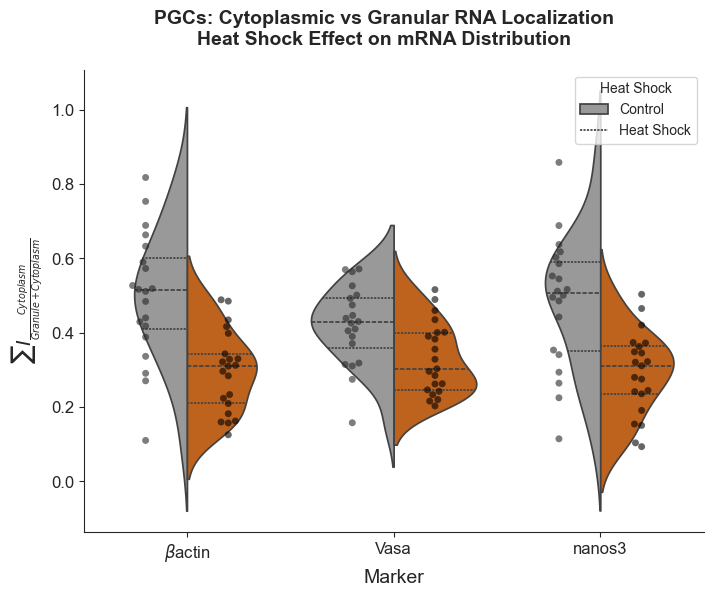

In [56]:
fig_pgc_cyto_gran_ratio_sum, ax_pgc_cyto_gran_ratio_sum = plt.subplots(figsize=(8, 6))
fig_pgc_cyto_gran_ratio_sum.suptitle('PGCs: Cytoplasmic vs Granular RNA Localization\nHeat Shock Effect on mRNA Distribution', fontsize=14, fontweight='bold')
sns.violinplot(data=df_cytoplasm_granule_ratio_sum.query("is_PGC == True"),
               x='marker_name',
               y='portion_cytoplasm_to_granule_ratio',
               hue='is_heatshock',
               split=True,
               palette=heat_shock_palette,
               inner='quart',
               ax=ax_pgc_cyto_gran_ratio_sum)
sns.swarmplot(data=df_cytoplasm_granule_ratio_sum.query("is_PGC == True"),
              x='marker_name',
              y='portion_cytoplasm_to_granule_ratio',
              hue='is_heatshock',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_pgc_cyto_gran_ratio_sum)
ax_pgc_cyto_gran_ratio_sum.set_ylabel(r"$\sum{I}_{\frac{Cytoplasm}{Granule+Cytoplasm}}$", fontsize=14)
ax_pgc_cyto_gran_ratio_sum.set_xlabel("Marker", fontsize=14)
ax_pgc_cyto_gran_ratio_sum.legend(title='Heat Shock', labels=['Control', 'Heat Shock'], loc='upper right')
ax_pgc_cyto_gran_ratio_sum.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_cyto_gran_ratio_sum.get_xticklabels()], fontsize=12)
ax_pgc_cyto_gran_ratio_sum.set_yticklabels(ax_pgc_cyto_gran_ratio_sum.get_yticklabels(), fontsize=12)
sns.despine()
fig_pgc_cyto_gran_ratio_sum.savefig(root / 'pgc_cytoplasm_granule_ratio_heatshock_effect_sum_intensity_of-all.pdf', bbox_inches='tight')

/var/folders/bt/4z5pqg251x7_jy1ww6tm92br0000gn/T/ipykernel_71995/3750567586.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_pgc_soma_comparison_sum.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_soma_comparison_sum.get_xticklabels()], fontsize=12)


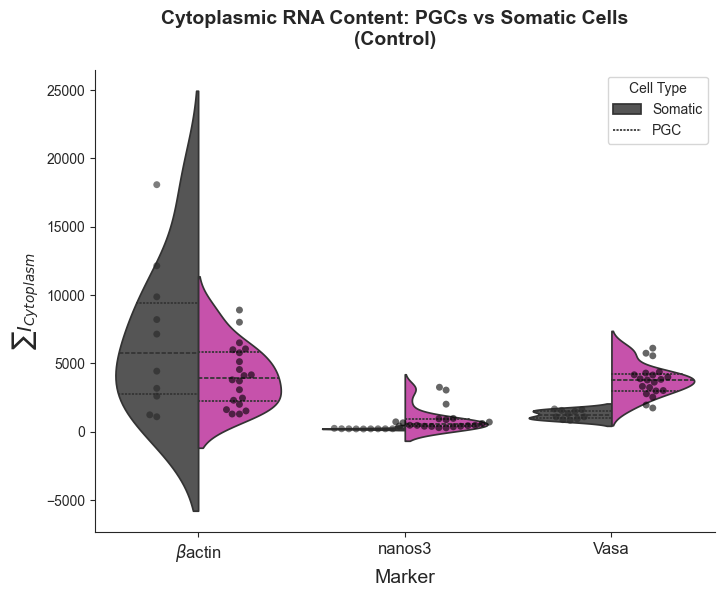

In [57]:
fig_pgc_soma_comparison_sum, ax_pgc_soma_comparison_sum = plt.subplots(figsize=(8, 6))
fig_pgc_soma_comparison_sum.suptitle('Cytoplasmic RNA Content: PGCs vs Somatic Cells\n(Control)', fontsize=14, fontweight='bold')
sns.violinplot(data=df_main.query("area_name == 'cytoplasm' and is_heatshock == False"),
               x='marker_name',
               y='mean_intensity',
               hue='is_PGC',
               split=True,
               palette=pgc_soma_palette,
               inner='quart',
               ax=ax_pgc_soma_comparison_sum,
               density_norm="width")
sns.swarmplot(data=df_main.query("area_name == 'cytoplasm' and is_heatshock == False"),
              x='marker_name',
              y='mean_intensity',
              hue='is_PGC',
              dodge=True,
              palette='dark:k',
              alpha=0.6,
              ax=ax_pgc_soma_comparison_sum)
ax_pgc_soma_comparison_sum.set_ylabel(r"$\sum{I}_{Cytoplasm}$", fontsize=14)
ax_pgc_soma_comparison_sum.set_xlabel("Marker", fontsize=14)
ax_pgc_soma_comparison_sum.legend(title='Cell Type', labels=['Somatic', 'PGC'], loc='upper right')
ax_pgc_soma_comparison_sum.set_xticklabels([marker_labels.get(label.get_text(), label.get_text()) for label in ax_pgc_soma_comparison_sum.get_xticklabels()], fontsize=12)
sns.despine()
fig_pgc_soma_comparison_sum.savefig(root / 'pgc_soma_cytoplasm_control_comparison_sum.pdf', bbox_inches='tight')